### Train YOLO11 with manually annotated masks to detect the car hood and the gray mask

In [ ]:
import cv2
from ultralytics import YOLO
import numpy as np
import os
import prepare_yolo_database

In [23]:
# Execute the python script prepare_yolo_dataset.py
!python prepare_yolo_database.py

First few matched pairs (sanity check):
       WE1H2XH4.jpg  <->  WE1H2XH4.jpg
       WE1H2XH5.jpg  <->  WE1H2XH5.jpg
       WE1H2XH6.jpg  <->  WE1H2XH6.jpg
       ... 228 pairs total

Found 228 pairs -> 193 train / 35 val

Done. Dataset written to: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_segmentation\yolo_finetune_images
data.yaml:
path: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_segmentation\yolo_finetune_images
train: images/train
val: images/val

names:
  0: object

Sanity check image ('train/WE1H2XMS.jpg') written to: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_segmentation\yolo_finetune_images\sanity_check.jpg


In [24]:
prepare_yolo_database.draw_sanity_check(prepare_yolo_database.OUTPUT_ROOT)

Sanity check image ('train/WE1H2XOC.jpg') written to: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_segmentation\yolo_finetune_images\sanity_check.jpg


In [ ]:
model.train(data="yolo_finetune_images/data.yaml", epochs=50, imgsz=640, freeze=10, batch=2) # freeze backbone

In [30]:
model.save("yolo26n-seg_finetuned.pt")

In [26]:
model = YOLO("yolo26n-seg_finetuned.pt")

In [27]:
image = cv2.imread("yolo_finetune_images/images/val/WE1H2XMH.jpg")
results = model(image, imgsz=640)


0: 640x640 1 object, 20.1ms
Speed: 3.8ms preprocess, 20.1ms inference, 9.2ms postprocess per image at shape (1, 3, 640, 640)


In [28]:
# Plot the results
import matplotlib.pyplot as plt

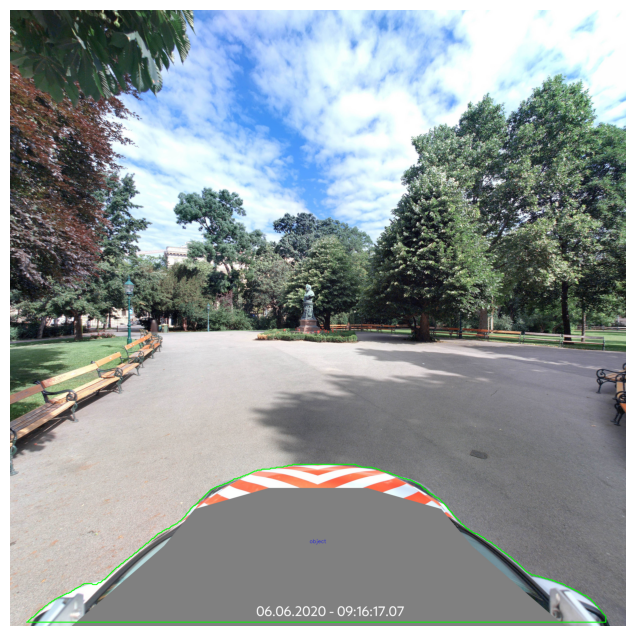

In [29]:
vis_image = image.copy()

for result in results:
	if result.masks is None:
		continue

	for mask, box in zip(result.masks.xy, result.boxes):
		class_id = int(box.cls[0])
		label = model.names[class_id]

		points = np.array(mask, dtype=np.int32).reshape((-1, 1, 2))
		cv2.polylines(vis_image, [points], isClosed=True, color=(0, 255, 0), thickness=10)

		x1, y1, x2, y2 = map(int, box.xyxy[0])
		center_x = (x1 + x2) // 2
		center_y = (y1 + y2) // 2
		cv2.putText(
			vis_image,
			label,
			(center_x, center_y),
			cv2.FONT_HERSHEY_SIMPLEX,
			2.0,
			(255, 0, 0),
			2,
			cv2.LINE_AA
		)

plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.gcf().set_size_inches(8, 8)
plt.show()

In [31]:
!yolo detect val model=yolo26n-seg_finetuned.pt data=yolo_finetune_images/data.yaml

WARNING conflicting 'task=detect' passed with 'task=segment' model. Ignoring 'task=detect' and updating to 'task=segment' to match model.
Ultralytics 8.4.78  Python-3.12.13 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4070, 12281MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients
val: Fast image access  (ping: 0.10.1 ms, read: 1834.3159.1 MB/s, size: 4724.7 KB)

val: Scanning F:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_finetune_images\labels\val.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 33% ━━━━──────── 1/3 23.8s/it 7.1s<47.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 66% ━━━━━━━━──── 2/3 4.2s/it 8.6s<4.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     M